# Notebook for experiments with skeletonization

Imports

In [1]:
import sys
import os

# Go up three levels from the notebook's directory (../src) to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..')) 
# Add the src directory to the path
src_path = os.path.join(project_root, 'src') 
if src_path not in sys.path:
    sys.path.insert(0, src_path)
    
        
print(f"Project Root: {project_root}")
print(f"Src Path added: {src_path}")
print(f"sys.path[0]: {sys.path[0]}") 

Project Root: /Users/mlapin/Development/personal/NaturalAGI
Src Path added: /Users/mlapin/Development/personal/NaturalAGI/src
sys.path[0]: /Users/mlapin/Development/personal/NaturalAGI/src


In [2]:
from typing import List
import numpy as np
import networkx as nx
import os
from cv2 import imread
from ypstruct import structure
import matplotlib.pyplot as plt
import numpy as np


from skeletonization.converter import Converter
from skeletonization.network_simplification import NetworkSimplification
from skeletonization.skeleton_gng_mapper import SkeletonGNGMapper
from skeletonization.settings import Settings, gng_parameters

Additional parameters:

In [3]:
epsilon = 6
binary_threshold = 160

Iterate over images in folder function

In [4]:
def iterate_over_images_in_folder(folder_path: str):
    for file in os.listdir(folder_path):
        if file.endswith((".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif")):
            yield file


In [5]:
from pydantic import BaseModel
from dataclasses import dataclass
from typing import Generator, Any, Tuple, Optional
import networkx as nx

class Vector(BaseModel):
    id: str
    x1: float
    y1: float
    x2: float
    y2: float
    length: float

@dataclass
class Point:
    x: float
    y: float
    id: str

    def __hash__(self):
        return hash(self.id)

class GraphTraversal:
    def __init__(self, graph: nx.Graph):
        self.graph = graph

    def dfs_traversal(self, start_node: Any) -> Generator[Tuple[Point, Optional[Vector]], None, None]:
        visited_edges = set()

        def find_edge(x1: float, y1: float, x2: float, y2: float) -> Optional[dict]:
            for _, _, edge_data in self.graph.edges(data=True):
                if ((edge_data['x1'] == x1 and edge_data['y1'] == y1 and edge_data['x2'] == x2 and edge_data['y2'] == y2) or
                    (edge_data['x1'] == x2 and edge_data['y1'] == y2 and edge_data['x2'] == x1 and edge_data['y2'] == y1)):
                    return edge_data
            return None

        def _dfs(node_id: str, prev_x: Optional[float] = None, prev_y: Optional[float] = None):
            node_data = self.graph.nodes[node_id]
            point = Point(id=node_data["id"], x=node_data['x'], y=node_data['y'])
            
            incoming_vector = None
            if prev_x is not None and prev_y is not None:
                edge_data = find_edge(prev_x, prev_y, point.x, point.y)
                if edge_data:
                    incoming_vector = Vector(
                        id=edge_data['id'],
                        x1=prev_x,
                        y1=prev_y,
                        x2=point.x,
                        y2=point.y,
                        length=edge_data['length']
                    )
                else:
                    raise ValueError(f"Edge not found between {prev_x}, {prev_y} and {point.x}, {point.y}")
            
            yield point, incoming_vector

            for neighbor_id in self.graph.neighbors(node_id):
                edge = tuple(sorted([node_id, neighbor_id]))
                if edge not in visited_edges:
                    visited_edges.add(edge)
                    yield from _dfs(neighbor_id, point.x, point.y)

        yield from _dfs(start_node)

In [6]:
from typing import Tuple, Optional


def plot_graph_traversal(
    ax: plt.Axes, G: nx.Graph, traversal: List[Tuple[Point, Optional[Vector]]]
):
    """
    Plot the graph traversal with arrows on the given axes.

    Args:
        ax (plt.Axes): The matplotlib axes to plot on.
        G (nx.Graph): The NetworkX graph.
        traversal (List[Tuple[Point, Optional[Vector]]]): The traversal result.
    """
    # Plot all edges in light gray
    pos = {node: (G.nodes[node]["x"], G.nodes[node]["y"]) for node in G.nodes()}
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="lightgray", arrows=False)

    # Plot nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, node_color="lightblue")

    # Plot traversal with arrows
    for i, (point, vector) in enumerate(traversal):
        # Mark the first point in red for better visualization
        if i == 0:
            ax.scatter(point.x, point.y, color='red', s=100, zorder=10)
            
        if vector:
            print(
                f"Vector {i}: x1: {vector.x1}, y1: {vector.y1}, x2: {vector.x2}, y2: {vector.y2}"
            )
            dx = vector.x2 - vector.x1
            dy = vector.y2 - vector.y1
            abs_dx = abs(dx)
            abs_dy = abs(dy)
            
            vector_type = None
            if abs_dx == abs_dy:
                vector_type = "DiagonalVector"
            elif abs_dx > abs_dy:
                vector_type = "HorizontalVector"
            else:
                vector_type = "VerticalVector"
            ax.arrow(
                vector.x1,
                vector.y1,
                dx,
                dy,  # Swap x and y
                head_width=3,
                head_length=3,
                fc="r",
                ec="r",
                length_includes_head=True,
                alpha=0.5,
            )
            
            label_x, label_y = calculate_label_position(vector)
            ax.text(
                label_x,
                label_y,
                vector_type,
                ha="center",
                va="center",
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
            )

        # Add numbers to show traversal order
        ax.text(point.x, point.y, str(i), fontsize=8, ha="center", va="center")

    ax.set_title("Graph Traversal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.invert_yaxis()  # Invert y-axis to match image coordinates

def calculate_label_position(vector: Vector, offset: float = 1) -> Tuple[float, float]:
    """
    Calculate optimal position for vector type label.
    
    Args:
        vector: Vector object containing coordinates
        offset: Distance of label from vector in pixels
        
    Returns:
        Tuple of (x, y) coordinates for label position
    """
    # Calculate vector properties
    dx = vector.x2 - vector.x1
    dy = vector.y2 - vector.y1
    length = vector.length
    
    # Calculate unit normal vector (perpendicular to the vector)
    if length > 0:
        nx = -dy / length
        ny = dx / length
    else:
        nx, ny = 0, -1
        
    # Calculate midpoint
    mid_x = vector.x1 + dx/2
    mid_y = vector.y1 + dy/2
    
    # Position label along normal vector
    label_x = mid_x + nx * offset
    label_y = mid_y + ny * offset
    
    return label_x, label_y


def plot_network_result(
    image_path,
    network,
    network_params: structure,
    points: np.ndarray,
    image: np.ndarray,
    binary: np.ndarray,
    skeleton: np.ndarray,
    simplified_network: List[List[np.ndarray]],
):
    # Create a figure with four subplots side by side
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(40, 10))

    # Plot original image on the left
    ax1.imshow(image, cmap="gray")
    ax1.set_title(f"Original Image: {image_path}")
    ax1.axis("off")

    ax2.imshow(binary, cmap="gray")
    ax2.set_title("Binary Image")
    ax2.axis("off")

    # Plot skeletonized image in the middle-left
    ax3.imshow(skeleton, cmap="gray")
    ax3.set_title("Skeletonized Image")
    ax3.axis("off")

    # Plot GNG result in the middle-right
    ax4.grid()
    ax4.scatter(points[:, 0], points[:, 1], s=2)
    for i in range(network_params.N):
        for j in range(i + 1, network_params.N):
            if network.C[i, j] == 1:
                ax4.plot(
                    [network.w[i, 0], network.w[j, 0]],
                    [network.w[i, 1], network.w[j, 1]],
                    c="r",
                )

    ax4.scatter(network.w[:, 0], network.w[:, 1], s=60, c="y", edgecolors="r")

    ax4.set_title("GNG")
    ax4.set_xlabel("x")
    ax4.set_ylabel("y")
    ax4.axis("equal")
    ax4.invert_yaxis()  # Invert y-axis to match image coordinates

    # Plot simplified network on the right
    ax5.grid()
    ax5.scatter(points[:, 0], points[:, 1], s=2, alpha=0.3)
    for segment in simplified_network:
        ax5.plot(segment[:, 0], segment[:, 1], "r-", linewidth=2)

    ax5.set_title("Simplified Network")
    ax5.set_xlabel("x")
    ax5.set_ylabel("y")
    ax5.axis("equal")
    ax5.invert_yaxis()  # Invert y-axis to match image coordinates

    plt.tight_layout()
    plt.show()

In [7]:
def find_top_leftmost_point(graph: nx.Graph) -> Optional[Any]:
    """
    Finds the top-leftmost point in the graph based on x and y coordinates.
    If no nodes with degree 1 exist, returns the node with highest degree.

    Returns:
        Optional[Any]: The top-leftmost point node or None if the graph is empty.
    """
    if not graph.nodes:
        return None

    degree_one_nodes = [node for node in graph.nodes if graph.degree[node] == 1]
    
    if degree_one_nodes:
        return min(
            degree_one_nodes,
            key=lambda n: graph.nodes[n]["y"] + graph.nodes[n]["x"],
        )
    else:
        # Find node with maximum degree
        return max(graph.nodes, key=lambda n: graph.degree[n])

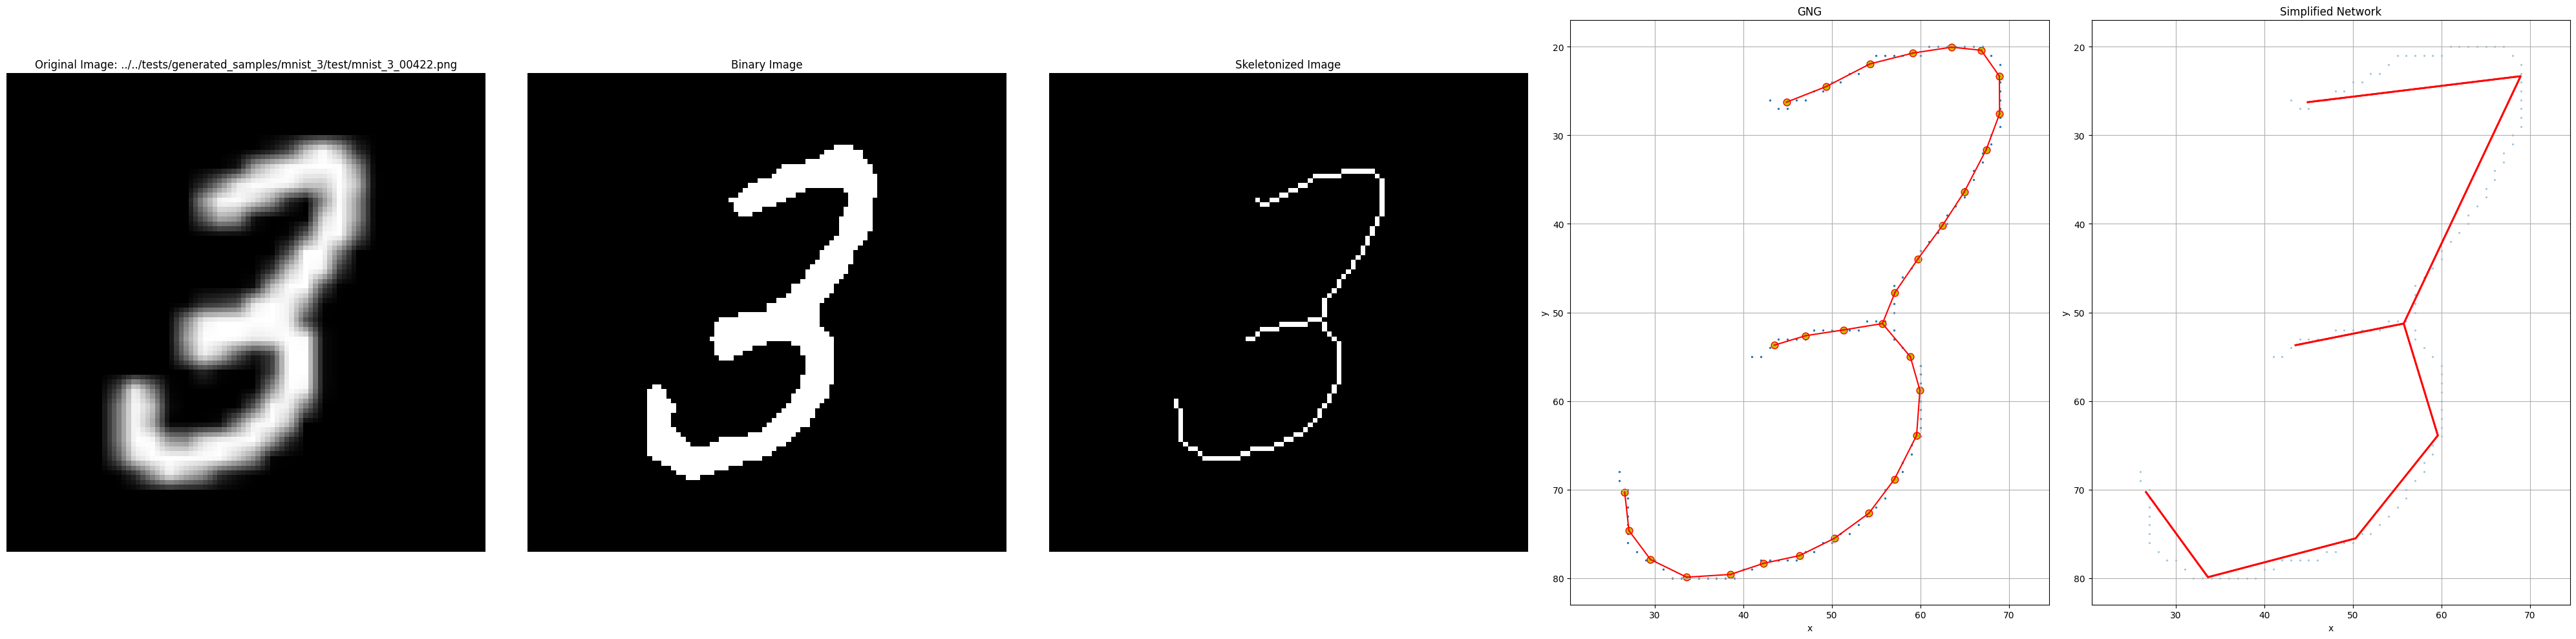

Cycles: 0
Top leftmost point: {'x': 44.89095375009845, 'y': 26.254890700883486, 'id': 'a9ff1f94-b360-4aff-b41c-fcdecd71d9e6'}
Vector 1: x1: 44.89095375009845, y1: 26.254890700883486, x2: 68.92696417408898, y2: 23.318363939020468
Vector 2: x1: 68.92696417408898, y1: 23.318363939020468, x2: 55.72456199856479, y2: 51.260204999314084
Vector 3: x1: 55.72456199856479, y1: 51.260204999314084, x2: 43.511800422666305, y2: 53.70084205665732
Vector 4: x1: 55.72456199856479, y1: 51.260204999314084, x2: 59.579987468595185, y2: 63.900294609640774
Vector 5: x1: 59.579987468595185, y1: 63.900294609640774, x2: 50.29920438500366, y2: 75.51968062218226
Vector 6: x1: 50.29920438500366, y1: 75.51968062218226, x2: 33.625334761736816, y2: 79.9072755416615
Vector 7: x1: 33.625334761736816, y1: 79.9072755416615, x2: 26.627599019205977, y2: 70.29027346420507


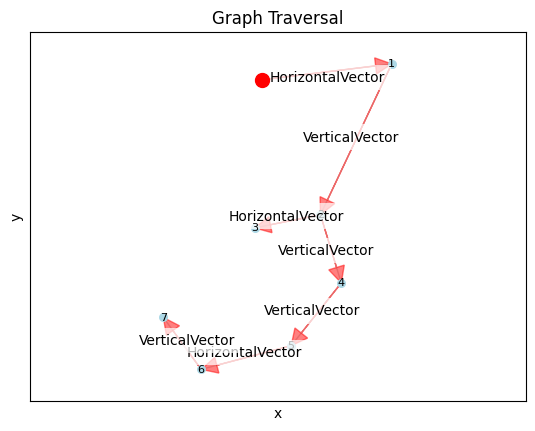

In [9]:
settings = Settings(
    kafka_topic="dummy",
    dlq_topic="dummy",
    kafka_bootstrap_servers="dummy",
    N=30,
    maxit=70,
    L=100,
    epsilon_b=0.2,
    epsilon_n=0.01,
    alpha=0.5,
    delta=0.995,
    T=50,
)

skeleton_gng_mapper = SkeletonGNGMapper(
    settings=settings, skeletonization_threshold=180, simplification_epsilon=5
)

# Get 10 random images from the folder
folder_path = "../../tests/prepared_samples/1_1"
# folder_path = '../../tests/generated_samples/mnist_1/train'
images = [
    os.path.join(folder_path, file)
    for file in sorted(os.listdir(folder_path))
    if file.endswith((".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif"))
]

class_number = 3
img_num = 422
image_id = f"mnist_{class_number}_{img_num:05d}.png"
local_path = f"../../tests/generated_samples/mnist_{class_number}/test"
images = [os.path.join(local_path, image_id)]

for image_path in images:
    image = imread(image_path, 0)
    # binary_threshold = threshold_otsu(image)
    # print(f"Binary threshold: {binary_threshold}")
    simplified_network, threshold = skeleton_gng_mapper.process_image(image)
    binary = skeleton_gng_mapper.binary_image(image, threshold)
    skeleton = skeleton_gng_mapper.skeletonize(image, threshold)
    image_points = skeleton_gng_mapper.skeleton_to_points(skeleton)
    network = skeleton_gng_mapper.fit_gng(image_points)
    simplified_network = NetworkSimplification.simplify_network(
        network, epsilon=skeleton_gng_mapper.simplification_epsilon
    )
    plot_network_result(
        image_path,
        network,
        gng_parameters(settings),
        image_points,
        image,
        binary,
        skeleton,
        simplified_network,
    )

    G = Converter.convert_simplified_network_to_networkx(simplified_network)

    cycles = list(nx.simple_cycles(G))
    print(f"Cycles: {len(cycles)}")
    if not nx.is_connected(G):
        print(f"Graph {image_path} is not connected")
        continue
    top_leftmost_point = find_top_leftmost_point(G)
    print(f"Top leftmost point: {G.nodes[top_leftmost_point]}")
    traversal = GraphTraversal(G).dfs_traversal(start_node=top_leftmost_point)

    plot_graph_traversal(plt.gca(), G, traversal)
    plt.show()